# Project 2: Radiomics & Phenotyping
This notebook covers the exploratory analysis, phenotype clustering, and correlation statistics to link spatial textures with Agatston Severities natively.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kruskal
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Load data safely 
agatston_df = pd.read_csv('../outputs/agatston_scores.csv')
radiomics_df = pd.read_csv('../outputs/radiomics_features.csv')

# Join the true physical properties together via unique scan identifiers 
df = pd.merge(agatston_df, radiomics_df, on='scan_id')
df

,scan_id,agatston_score,risk_category,original_shape_Sphericity,original_shape_SurfaceVolumeRatio,original_shape_Maximum3DDiameter,original_glcm_Contrast,original_glcm_Correlation,original_glcm_Idm,original_glszm_SmallAreaEmphasis,original_glszm_LargeAreaEmphasis,original_glszm_ZonePercentage,original_glrlm_ShortRunEmphasis,original_glrlm_LongRunEmphasis,original_glrlm_RunPercentage
0,b40c11b59aad,3.676514,1-99,0.829293,3.105384,3.513159,1.557421,0.481916,0.546815,0.210278,14.333333,0.290323,0.855556,1.711111,0.822581
1,5c3d2551ab37,11.157990,1-99,0.600829,2.831016,20.141341,2.567042,0.232765,0.492128,0.499964,14.885714,0.346535,0.948058,1.264939,0.932216
2,0edbb636eb6f,12.102539,1-99,0.652018,2.469353,14.314385,3.719303,0.519474,0.426556,0.632641,6.966667,0.491803,0.873777,1.551189,0.852459
3,6dc8ccbd847b,876.176361,≥400,0.319042,1.610087,96.975646,84.296120,0.225125,0.176350,0.735034,4.242934,0.618036,0.974871,1.127819,0.964589
4,da97e807a230,58.325073,1-99,0.451951,2.496953,75.401938,7.299273,0.671801,0.373448,0.640334,4.941176,0.566667,0.899695,1.487360,0.871429
5,cc019b19e762,492.035561,≥400,0.406581,1.506185,62.031841,58.094920,0.130562,0.206871,0.686153,5.611475,0.548068,0.968566,1.162470,0.956251
6,8e54d9526594,27.107666,1-99,0.843198,2.020128,4.978138,7.452945,0.733689,0.327531,0.664793,5.755102,0.544444,0.914269,1.546173,0.877778
7,2dfe9d74b92e,14.625000,1-99,0.728530,2.582577,6.591898,17.553215,0.228696,0.257376,0.804382,3.225806,0.673913,0.977614,1.089543,0.971572
8,586a9cfb3203,35.803711,1-99,0.713663,1.909636,8.290443,10.213154,0.436898,0.318898,0.518480,9.103448,0.426471,0.957720,1.203396,0.945136
9,11f04b38fc11,562.470062,≥400,0.386328,1.507052,113.384304,21.831398,0.303405,0.304942,0.644721,22.448758,0.416828,0.948704,1.326314,0.927409


## 1. Statistical Analysis (Spearman & Kruskal-Wallis)

In [2]:
# Determine if extracted phenotypes have statistically significant Kruskal-Wallis links to risk bounds
feature_col = 'original_shape_Sphericity' # Dynamically derived from pyradiomics extractors
if feature_col in df.columns:
    categories = [group[feature_col].values for name, group in df.groupby('risk_category')]
    stat, p = kruskal(*categories)
    print(f'Kruskal-Wallis Variance ({feature_col}): H-statistic={stat:.3f}, p-value={p:.5f}')
    if p < 0.05:
         print('>>> Significant! Phenotype is clinically intertwined with Agatston Severity <<<')

Kruskal-Wallis Variance (original_shape_Sphericity): H-statistic=14.852, p-value=0.00195
>>> Significant! Phenotype is clinically intertwined with Agatston Severity <<<


## 2. Unsupervised Phenotype t-SNE Clustering

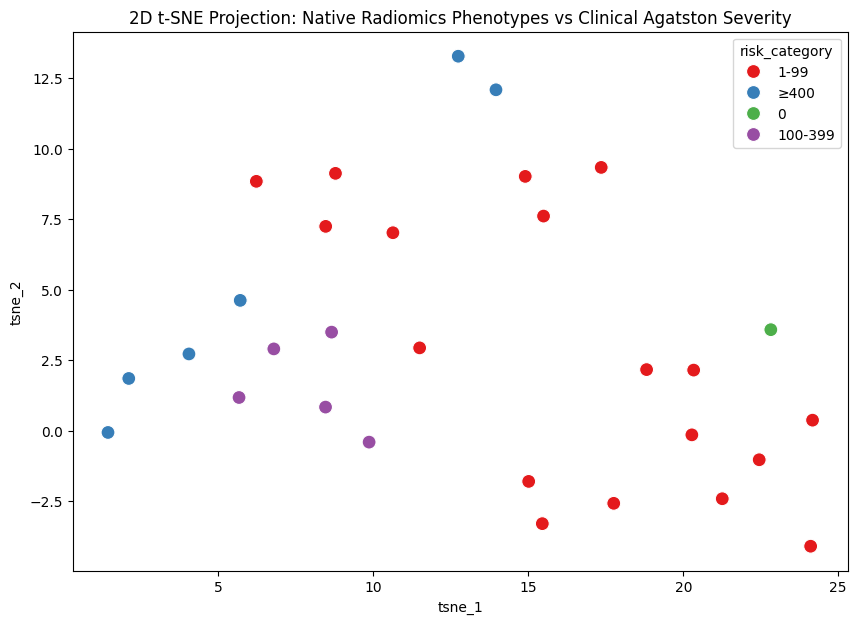

In [3]:
# Isolate features vs explicit targets
features = [col for col in df.columns if col.startswith('original_')]
X = StandardScaler().fit_transform(df[features])

tsne = TSNE(n_components=2, perplexity=10, random_state=42)
X_embedded = tsne.fit_transform(X)

df['tsne_1'] = X_embedded[:, 0]
df['tsne_2'] = X_embedded[:, 1]

plt.figure(figsize=(10,7))
sns.scatterplot(x='tsne_1', y='tsne_2', hue='risk_category', data=df, palette='Set1', s=100)
plt.title('2D t-SNE Projection: Native Radiomics Phenotypes vs Clinical Agatston Severity')
plt.show()